In [1]:
import pypsa
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,



**1) Zeitachse (Monatsanfang) definieren:**
- pd.date_range erzeugt eine Folge gleich großer Zeitpunkte.
- Mit periods=12 kommt eine Serie mit 12 Stempeln heraus.
- freq="MS" bedeutet Month Start (Monatsanfang), also 2019-01-01, 2019-02-01, …, 2019-12-01.
- Dadurch entsteht eine monatliche Zeitachse mit je einem Zeitstempel pro Monat.
- In Energiesystem-Modellen nennt PyPSA die Zeitpunkte snapshots; die Optimierung läuft dann über genau diese Index-werte.


In [2]:
snapshots = pd.date_range("2019-01-01", periods=12, freq="MS")

**2) PyPSA-Netz & Snapshots definieren:**
- pypsa.Network() erzeugt ein leeres Netzwerksobjekt – den Container für alle Komponenten (Busse, Generatoren, Lasten, …) und für alle Zeitreihen
- n.set_snapshots(snapshots) hinterlegt die Zeitachse im Netzwerk
- Dabei werden alle zeitabhängigen Tabellen von PyPSA auf diese Indizes reindiziert
- Dummy-Netz (nur damit create_model() läuft) ---


In [3]:
n = pypsa.Network()
n.set_snapshots(snapshots)

n.add("Carrier", "dummy")
n.add("Bus", "bus0", carrier="dummy")
n.add("Generator", "dummy_gen", bus="bus0",
      p_nom=1.0, p_min_pu=0.0, p_max_pu=0.0,
      marginal_cost=1e-6)  # <- kleine Kosten, damit PyPSA eine Objective bauen kann

Index(['dummy_gen'], dtype='object')

**3.1) Parameter crops: Liste der betrachteten Pflanzen:**
- Die Reihenfolge wird später als Spaltenachse eines Datenfelds benutzt.
:**
- Parameter crops: Liste der betrachteten Pflanzen:
- Die Reihenfolge wird später als Spaltenachse eines Datenfelds benutzt.

In [4]:
crops = ["Tomate","Paprika","Gurke","Salat","Zucchini","Kohlrabi",
         "Spinat","Kartoffel","Erdbeere","Sojabohne", "Linsen", "Kichererbsen",
         "Bohnen", "Mangold", "Radisschen", "Rote Bete", "Suesskartoffel"]

**3.2) Parameter: Ertrag der Pflanzen kg/m^2 pro Jahr (Ernten) in Snapshots (gesamte Biomasse betrachtet):**
- Ertrag der Pflanzen kg/m^2 pro Jahr (Ernten) in Snapshots (gesamte Biomasse betrachtet)
- Das ist ein 2D-Numpy-Array mit Form (12, 17): 12 Zeilen (= Monate), 17 Spalten (= Kulturen).
- Jede Zahl ist ein Monats-Ertrag in kg/m².
- dtype=float erzwingt Fließkomma-Zahlen.

In [5]:
yield_matrix = np.array([
    [0,   0,   0, 4.7, 0,   0,   2.1, 0,   0,   0,  0,   0,   0,   0,     2.5,   0,   0],  # Jan
    [0,   0,   0, 4.7, 0,   0,   2.1, 0,   0,   0,  0,   0,   2.9, 0,     5,     0,   0],  # Feb
    [54,  0,   0, 4.7, 6.2, 4.8, 2.1, 6.5, 5.8, 1,  0.3, 0,   0,   8.3,   2.5,   7.6, 0],  # Mär
    [0,  18.5,40, 4.7, 0,   0,   2.1, 0,   0,   0,  0,   0.4, 2.9, 8.3,   5,     7.6, 10],  # Apr
    [0,   0,   0, 4.7, 0,   0,   2.1, 0,   0,   0,  0,   0,   0,   8.3,   2.5,   7.6, 0],  # Mai
    [54,  0,   0, 4.7, 6.2, 4.8, 2.1, 6.5, 5.8, 1,  0.3, 0,   2.9, 8.3,   5,     7.6, 0],  # Jun
    [0,   0,   0, 4.7, 0,   0,   2.1, 0,   0,   0,  0,   0,   0,   8.3,   2.5,   7.6, 0],  # Jul
    [0,  18.5,40, 4.7, 0,   0,   2.1, 0,   0,   0,  0,   0.4, 2.9, 8.3,   5,     7.6, 10],  # Aug
    [54,  0,   0, 4.7, 6.2, 4.8, 2.1, 6.5, 5.8, 1,  0.3, 0,   0,   8.3,   2.5,   7.6, 0],  # Sep
    [0,   0,   0, 4.7, 0,   0,   2.1, 0,   0,   0,  0,   0,   2.9, 8.3,   5,     7.6, 0],  # Okt
    [0,   0,   0, 4.7, 0,   0,   2.1, 0,   0,   0,  0,   0,   0,   8.3,   2.5,   7.6, 0],  # Nov
    [54, 18.5,40, 4.7, 6.2, 4.8, 2.1, 6.5, 5.8, 1,  0.3, 0.4, 0,   0,     5,     0,   10],  # Dez
], dtype=float)

- Damit wird das Numpy-Array in ein xarray.DataArray verwandelt – mit benannten Dimensionen ["snapshot","crop"]
- Ein xarray.DataArray ist so ähnlich wie eine mehrdimensionale Tabelle (wie eine erweiterte Version von NumPy Arrays).
- dims = beschreibt die Achsen, also wie die Dimensionen heißen:
- dims=["snapshot","crop"] -->  Achse 1 = Zeit, Achse 2 = Pflanzensorte.
coords = die Labels, die zu diesen Dimensionen gehören:
- coords={"snapshot": n.snapshots, "crop": crops}
- snapshot bekommt echte Datumsangaben (01.01.2019, 01.02.2019, …).
- → crop bekommt Namen wie „Tomate“, „Paprika“, „Gurke“ usw.
- Das ist viel verständlicher als nur mit reinen Zahlenindizes (0,1,2,…).
- Durch die benannten Achsen + Labels kannst du jetzt sehr intuitiv mit den Daten umgehen.
- Beispiele: yield_per_area.sel(snapshot="2019-03-01", crop="Tomate") .sel(...) = „select by label“. Methode von xarray, mit der nach Labels ausgewählt werden kann.
- → liefert dir direkt den Ertrag von Tomaten im März 2019.
- (Ohne xarray müsste man mühsam Index 2 für März und Index 0 für Tomate nehmen.)

In [6]:
yield_per_area = xr.DataArray(
    yield_matrix,
    coords={"snapshot": n.snapshots, "crop": crops},
    dims=["snapshot","crop"],
)

**3.3) Parameter: Energieverbrauch pro m² und Kultur (kWh/m²/Jahr) :**
- Das ist ein 1D-Vektor: eine Liste von Zahlen mit genau einem Wert pro Kultur.
- dims=["crop"]: die Achse heißt hier "crop" (anstatt nur 0,1,2,…).
- coords={"crop": crops}: jeder Eintrag bekommt ein Label (Tomate, Paprika, Gurke, …).
- --> dims=["crop"] benennt die Achse, und coords={"crop": crops} gibt dieser Achse die Pflanzennamen als Labels.:
- → Damit weiß xarray: Der erste Wert (2700) gehört zu Tomate, der zweite (696) zu Paprika usw.
- Vorteil: Du kannst später direkt mit Labels arbeiten, z. B. energy_per_area.sel(crop="Tomate").
- Ohne coords/dims wäre es nur eine anonyme Liste, bei der du den Index kennen musst (0 = Tomate).

In [7]:
energy_per_area = xr.DataArray(
    [2700, 696, 1425, 212, 181, 201, 81, 293, 102, 30, 7, 14, 70, 250, 86, 297, 300],  # Reihenfolge = crops
    coords={"crop": crops},
    dims=["crop"]
)

- Jahreswerte auf Monatswerte runterskalieren:
Jeder Wert im Vektor energy_per_area (kWh/m² pro Jahr) wird durch 12 geteilt.
- → Dadurch Werte in kWh/m² pro Monat

In [8]:
energy_per_area_month = energy_per_area / 12.0

**3.4) ährstoffe der Ernte/ Pflanzen (kcal/kg/Ernte), ...:**
- Jeder dieser DataArrays ist ein Vektor über die Achse crop.
- Er enthält Nährwerte pro Kilogramm Ernte für jede Pflanze.

In [9]:
kcal_per_kg = xr.DataArray([190, 430, 140, 140, 190, 270, 220, 760, 360, 1490, 3620, 3150, 3370, 210, 170, 600, 860],
                           coords={"crop": crops}, dims=["crop"])

prot_per_kg = xr.DataArray([7, 13, 6, 12, 18, 19, 28, 20, 8.2, 120, 270, 200, 225, 24, 11, 11, 16],
                            coords={"crop": crops}, dims=["crop"])

carb_per_kg  = xr.DataArray([35, 64, 18, 11, 20, 37, 6, 156, 55.1, 40, 550, 480, 469, 20, 21, 124, 200],
                            coords={"crop": crops}, dims=["crop"])

sugar_per_kg = xr.DataArray([32, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 20, 124, 42],
                            coords={"crop": crops}, dims=["crop"])

fiber_per_kg = xr.DataArray([10, 35.9, 9, 15, 10, 14, 18, 21, 20, 30, 170, 170, 152, 26, 15, 17, 30],
                            coords={"crop": crops}, dims=["crop"])

fat_per_kg   = xr.DataArray([1, 5, 2, 2, 2, 1, 3, 1, 4, 100, 26, 56, 10, 3, 1, 1, 1],
                            coords={"crop": crops}, dims=["crop"])

**3.5) Ernährungsbedarf pro Person pro Monat:**
- Alle demands sind hier monatskonstant modelliert; Dimension = 'snapshot'.
- coords={"snapshot": n.snapshots} und dims=["snapshot"] - Verankert die Serie sauber auf der Zeitachse deines PyPSA-Netzes.
- Jede Zahl ist einem Monats-Snapshot (2019-01-01, …, 2019-12-01) zugeordnet

In [10]:
# 2250 kcal am Tag * 30 = Monatsbedarf - vereinfachte Annahme
demand_kcal = xr.DataArray([2250*30]*len(n.snapshots),
                           coords={"snapshot": n.snapshots}, dims=["snapshot"])
# 55 g Proteine am Tag
demand_prot  = xr.DataArray([55*30]*len(n.snapshots),
                             coords={"snapshot": n.snapshots}, dims=["snapshot"])
# 260 g Carbohydraten am Tag
demand_carb  = xr.DataArray([260*30]*len(n.snapshots),
                            coords={"snapshot": n.snapshots}, dims=["snapshot"])
# 25 g Sugar am Tag
demand_sugar = xr.DataArray([25*30]*len(n.snapshots),
                            coords={"snapshot": n.snapshots}, dims=["snapshot"])
# 30 g Fiber am Tag
demand_fiber = xr.DataArray([30*30]*len(n.snapshots),
                            coords={"snapshot": n.snapshots}, dims=["snapshot"])
# 75 g Fett am Tag
demand_fat   = xr.DataArray([75*30]*len(n.snapshots),
                            coords={"snapshot": n.snapshots}, dims=["snapshot"])

**3.6) Parameter: Fläche definieren**

In [11]:
Amax_total = 100.0  # m²

**3.7) Parameter: Lager Werte**
- Anfangs-Lager: Faktor × Monatsbedarf (z. B. 1.0 = ein Monatsbedarf als Startlager ist gedeckt)

In [12]:
S_init_factor = 1.0

**4) Linopy-Modell erzeugen**
- Optimierungsmodel mit Linopy definieren (nutzt Pypsa im Hintergrund)
- n.(...) ist dein PyPSA-Netzwerk mit Snapshots etc.
- n.optimize.create_model() baut daraus ein Linopy-Optimierungsmodell
- m.(..) enthält Variablen, Constraints, Zielfunktion.

In [13]:
m = n.optimize.create_model()

**4.1) Entscheidungsvariablen --> entscheidet die Zielfunktion**

**build**
- build (Binärvariable, nur 0 oder 1): Für jede Pflanze (crop)
- → soll sie grundsätzlich angebaut werden (1) oder nicht (0)?
- → Dimension: nur eine Achse: "crop" bekommt genau eine Variable (0/1)

**active**
- active (Binärvariable, 0/1 für jede Pflanze in jedem Monat):
- Gibt an: ist Pflanze im Monat t aktiv angebaut oder nicht?
- → Dimension: "snapshot" × "crop" um zu sagen in welchem Monat welche Pflanze angebaut wird

**area**
- lower=0.0 → die Variable darf nicht negativ werden (Fläche kann nicht kleiner als 0 sein)
- area (Rechteckvariable, Fläche pro Monat pro Pflanze):
- Gibt an: welche Fläche wird für jede Pflanze im Monat angebaut?
- → Dimension: "snapshot" × "crop" um zu sagen in welchem Monat welche Pflanze welchen Platz einnehmen sollen


In [14]:
build  = m.add_variables(binary=True, name="build",  coords=[("crop", crops)])
active = m.add_variables(binary=True, name="active", coords=[("snapshot", n.snapshots), ("crop", crops)])
area   = m.add_variables(lower=0.0,   name="area",   coords=[("snapshot", n.snapshots), ("crop", crops)])

**4.2) Anbau-Constraints**

**build**
- Domänen: build[c] ∈ {0,1} (ein Schalter je Pflanze), active[t,c] ∈ {0,1} (ein Schalter je Monat und Pflanze).
- Eine Kultur darf in Monat t nur aktiv sein, wenn sie grundsätzlich gebaut/zugelassen wurde von der Zielfunktion"
- Das koppelt eine zeitunabhängige (build) mit einer zeitabhängigen (active) Entscheidung.

**active**
- Domänen: area[t,c] ≥ 0 (reell), active[t,c] ∈ {0,1}
- Einheiten: area ist m²; M=1e3 ist eine dimensionsbehaftete Obergrenze (m²)
- Aussage: Fläche darf nur dann positiv sein, wenn active=1, wenn active = 0 wird keine Fläche angebaut
- Das ist eine künstlich gesetzte Obergrenze für die Fläche pro Pflanze.
- Sie muss groß genug sein, dass sie realistisch nie bindend ist (sowieso nur 100 m² insgesamt verfügbar).
- Sie sorgt nur dafür: ohne Aktivierung (active=0) ist die Fläche = 0.
- Das * multipliziert die Binärvariable mit einem großen Wert (1e3 =  Big-M), um die Kopplung zwischen „aktiv“ und „Fläche“ herzustellen.
- Die Big-M-Methode übersetzt logische „wenn-dann“-Bedingungen in lineare Ungleichungen, indem man eine Binärvariable mit einer großen Konstante
- M multipliziert, sodass die andere Variable nur dann „aktiv“ werden darf, wenn die Binärvariable = 1 ist.

**area**
- area hat Dimensionen (snapshot, crop) und Einheit m².
- area.sum("crop") bildet für jeden Monat die Summe über alle Kulturen:
- für jeden Monat wird die Ungleichung erzeugt. Das ist die vektorisiert-kompakte Schreibweise von „für alle t: Summe der Flächen ≤ 100 m²
- Erst das Optimierungsmodell weist diesen Platzhaltern am Ende konkrete Werte zu (je nachdem, wie es die Constraints und das Zielproblem am besten erfüllt



In [15]:
m.add_constraints(active <= build, name="active<=build")
m.add_constraints(area   <= 1e3 * active, name="area_cap_if_active")  # "Big-M  Methode"
m.add_constraints(area.sum("crop") <= Amax_total, name="total_area_cap")  # Σ Fläche ≤ 100 m²

Constraint `total_area_cap` [snapshot: 12]:
-------------------------------------------
[2019-01-01 00:00:00]: +1 area[2019-01-01 00:00:00, Tomate] + 1 area[2019-01-01 00:00:00, Paprika] + 1 area[2019-01-01 00:00:00, Gurke] ... +1 area[2019-01-01 00:00:00, Radisschen] + 1 area[2019-01-01 00:00:00, Rote Bete] + 1 area[2019-01-01 00:00:00, Suesskartoffel] ≤ 100.0
[2019-02-01 00:00:00]: +1 area[2019-02-01 00:00:00, Tomate] + 1 area[2019-02-01 00:00:00, Paprika] + 1 area[2019-02-01 00:00:00, Gurke] ... +1 area[2019-02-01 00:00:00, Radisschen] + 1 area[2019-02-01 00:00:00, Rote Bete] + 1 area[2019-02-01 00:00:00, Suesskartoffel] ≤ 100.0
[2019-03-01 00:00:00]: +1 area[2019-03-01 00:00:00, Tomate] + 1 area[2019-03-01 00:00:00, Paprika] + 1 area[2019-03-01 00:00:00, Gurke] ... +1 area[2019-03-01 00:00:00, Radisschen] + 1 area[2019-03-01 00:00:00, Rote Bete] + 1 area[2019-03-01 00:00:00, Suesskartoffel] ≤ 100.0
[2019-04-01 00:00:00]: +1 area[2019-04-01 00:00:00, Tomate] + 1 area[2019-04-01 00:0

**4.3) Ernte - Nährstoffausbeute definieren:**
- multipliziert elementweise über die benannten Dimensionen (snapshot, crop).
- Die Achse crop ist bei allen beteiligten Arrays gleich benannt
- harvest_expr kann noch keinen fixen Wert ausrechnen, sondern steht symbolisch für „Ertrag = Ertrag pro m² × gewählte Fläche“. deswegen _expr
- Dimensionen: (snapshot, crop) → also eine Tabelle: Zeilen = Monate, Spalten = Pflanzen.
- Werte: „Wie viel kg von Pflanze X ernte ich im Monat t?“

In [16]:
harvest_expr = yield_per_area * area    # kg der Ernte

**Nährstoffproduktion je Monat**
- kcal_per_kg ist ein Vektor mit Kalorien pro kg Ernte, je Pflanze.
- Ergebnis: Wie viele Kalorien bringt die Ernte von Pflanze X im Monat t?
- .sum("crop") bedeutet: „summiere über die Dimension crop“. Addiere die Kalorien aller Pflanzen im gleichen Monat.
- Ergebnis: Man hat nur noch die Dimension snapshot → eine Zeitreihe mit „Gesamt-Kalorien je Monat“.
- Das Ganze wird in der Variablen prod_kcal_expr gespeichert
- expr = „Expression“ → erinnert daran: Das ist noch ein Rechenausdruck im Modell, kein fixer Wert.
- Diese Werte hängen davon ab, wie die Optimierung später die Fläche area zuweist.


In [17]:
prod_kcal_expr  = (harvest_expr * kcal_per_kg ).sum("crop")
prod_prot_expr  = (harvest_expr * prot_per_kg ).sum("crop")
prod_carb_expr  = (harvest_expr * carb_per_kg ).sum("crop")
prod_sugar_expr = (harvest_expr * sugar_per_kg).sum("crop")
prod_fiber_expr = (harvest_expr * fiber_per_kg).sum("crop")
prod_fat_expr   = (harvest_expr * fat_per_kg  ).sum("crop")

**5) Lagerdynamik für alle Nährstoffe (kcal & Makros) als Nebenbedingung erzwingt zeitliche Deckung**
- Die Funktion add_stock(...) baut für einen Nährstoff x (z. B. kcal) die zeitliche Lagerbilanz auf:
- m: das Linopy-Modell (Optimierungsmodell), in das wir Variablen/Constraints einfügen.
- name: Bezeichner des Lagers (z. B. "stock_kcal"), damit die Variablen/Constraints sprechende Namen haben.
- prod_expr: die monatliche Produktion des Nährstoffs als Ausdruck über die Zeit (kommt aus Ernte × Nährwert-Rechnung; dimensioniert über snapshot).
- demand: der monatliche Bedarf des Nährstoffs (DataArray über snapshot).
- snapshots: die Zeitachse
- S_init_factor: Multiplikator für den Startbestand in Einheiten des Monatsbedarfs; 1.0 bedeutet „ein Monatsbedarf auf Lager“.

**demand.isel**
- demand.isel(snapshot=0) greift den ersten Monatsbedarf heraus (Indexauswahl per Position „0“)
- .isel ist Xarray-Indexierung nach Position; sie arbeitet sauber entlang benannter Dimensionen.
- .isel = index select. - snapshot 0 = erster Monatsbedarf
- isel(snapshot=slice(1, None)) → nimm alle Zeitpunkte ab t=1 bis zum Ende.
- -> nicht „nimm die erste Spalte“, sondern „nimm die erste Zeitposition der Dimension snapshot“.
- Multiplikation mit S_init_factor liefert den Startbestand S0 in derselben Einheit wie demand (z. B. kcal).
- float(...) macht daraus eine feste Zahl (Parameter), die in die Startgleichung eingeht.

In [18]:
def add_stock(m, name, prod_expr, demand, snapshots, S_init_factor=1.0):
    stock = m.add_variables(lower=0.0, name=name, coords=[("snapshot", snapshots)]) # Lager-Variable anlegen, Dimension: snapshot, erst gelöst wernde Werte übergeben
    S_init = float(S_init_factor * demand.isel(snapshot=0))                         # Startlager berechnen
    # demand.isel(snapshot=0) greift den ersten Monatsbedarf heraus (Indexauswahl per Position „0“)
    # .isel ist Xarray-Indexierung nach Position; sie arbeitet sauber entlang benannter Dimensionen.
    # .isel = index select. - snapshot 0 = erster Monatsbedarf
    # isel(snapshot=slice(1, None)) → nimm alle Zeitpunkte ab t=1 bis zum Ende.
    # --> nicht „nimm die erste Spalte“, sondern „nimm die erste Zeitposition der Dimension snapshot“.
    # Multiplikation mit S_init_factor liefert den Startbestand S0 in derselben Einheit wie demand (z. B. kcal).
    # float(...) macht daraus eine feste Zahl (Parameter), die in die Startgleichung eingeht.

    # Bilanzgleichung für den ersten Monat t=0
    m.add_constraints(stock.isel(snapshot=0) ==
                      prod_expr.isel(snapshot=0) - demand.isel(snapshot=0) + S_init,
                      name=f"{name}_balance_t0")
    # S0 = Prod_0 - Bedarf_0 + S_init

    # Dynamik für alle Folgemonate
    # t=1..T-1
    m.add_constraints(
        stock.isel(snapshot=slice(1, None)) ==          # slice(1, None) bedeutet „ab Index 1 bis zum Ende; (slice(0, -1) bedeutet „vom Anfang bis zum vorletzten“)
        stock.isel(snapshot=slice(0, -1)) +
        prod_expr.isel(snapshot=slice(1, None)) -
        demand.isel(snapshot=slice(1, None)),
        name=f"{name}_balance_dyn"
    )
    # S_t = S_{t-1} + Prod_t - Bedarf_t --> damit wird zeitliche Deckung erzwungen
    # Wenn in einem Monat zu wenig produziert wird, muss das Lager etwas abgeben.
    # Ist das Lager leer, kann die Bedingung nicht erfüllt werden → der Optimierer muss dafür sorgen, dass vorher mehr angebaut wird.
    # Dadurch passt er automatisch die Flächen und Anbaumengen an.
    # Wir zwingen das Modell durch diese Gleichungen, dass Angebot, Nachfrage und Lager immer mathematisch exakt zusammenpassen.

    return stock  # Die Funktion liefert den Variablenvektor S_t zurück, damit später darauf in z. B. Grenzwerte, Zielfunktionen oder Ausgaben aufgebaut werden kann.


**Anwendung auf alle Nährstoffe: stock_kcal, ... = Entscheidungsvariablen im Optimierungsmodell**
- Funktion die oben definiert wurde aufrufen:
- enthalten später den Lagerbestand für jeden Nährstoff
- Für jede Nährstoffart x setzt man denselben Bilanzmechanismus auf, nur mit der passenden Produktion prod_x und dem Bedarf demand_x
- Jedes Mal, wenn du sie aufrufst, erstellt sie: eine neue Variable stock (das Lager über die Zeit),
- Constraints für Lagerbilanz (Start- und Dynamikbedingungen), und gibt die Variable zurück.


In [19]:
stock_kcal  = add_stock(m, "stock_kcal",  prod_kcal_expr,  demand_kcal,  n.snapshots, S_init_factor)
stock_prot  = add_stock(m, "stock_prot",  prod_prot_expr,  demand_prot,  n.snapshots, S_init_factor)
stock_carb  = add_stock(m, "stock_carb",  prod_carb_expr,  demand_carb,  n.snapshots, S_init_factor)
stock_sugar = add_stock(m, "stock_sugar", prod_sugar_expr, demand_sugar, n.snapshots, S_init_factor)
stock_fiber = add_stock(m, "stock_fiber", prod_fiber_expr, demand_fiber, n.snapshots, S_init_factor)
stock_fat   = add_stock(m, "stock_fat",   prod_fat_expr,   demand_fat,   n.snapshots, S_init_factor)


**6) Zielfunktion: Energieverbrauch minimieren**
- Zweck: Skalarer Ausdruck für den Gesamtenergieverbrauch.
- area ist eine Variable über (snapshot, crop) in m²; energy_per_area_month ist ein Parameter über crop in kWh/m²/Monat
- Operation 1 (Multiplikation): elementweise Multiplikation mit Label-Ausrichtung:
- Für jeden Monat und jede Kultur: m² × (kWh/m²/Monat) = kWh/Monat. Das Broadcasting passiert entlang der benannten Dimensionen
- Operation 2 (Summe): .sum(["crop","snapshot"]) reduziert zuerst über alle Kulturen, dann über alle Monate ⇒ ein einziger Skalar (GesamtkWh).
- Summieren über benannte Dimensionen ist Standard in xarray; Linopy folgt derselben API.

In [20]:
energy_use = (area * energy_per_area_month).sum(["crop","snapshot"])

**Zweck**
- Setzt die Zielfunktion auf „Minimiere energy_use“
- Das ist eine lineare Zielgröße (Summe aus Parametern×Variablen),
- Die Zielfunktion wird im Linopy-Modell m registriert, das über n.optimize verwaltet wird.

In [21]:
m.add_objective(energy_use, sense="min", overwrite=True)

**7) Lösen:**
- Zweck: Den bereits aufgebauten Linopy-Modellkern an den Solver übergeben und lösen.
- Wirkung: Der Solver berechnet konkrete Werte für alle Variablen (area, build, active, stock_* …), die die Nebenbedingungen erfüllen und die Zielfunktion minimieren.
- Ergebnisse werden an das Netzwerk/Modell zurückgeschrieben.


In [22]:
n.optimize.solve_model(solver_name="gurobi")

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io: Writing time: 0.08s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2694931


INFO:gurobipy:Set parameter LicenseID to value 2694931


...

Optimal solution found (tolerance 1.00e-04)


INFO:gurobipy:Optimal solution found (tolerance 1.00e-04)


Best objective 1.256751507523e+03, best bound 1.256751507523e+03, gap 0.0000%


INFO:gurobipy:Best objective 1.256751507523e+03, best bound 1.256751507523e+03, gap 0.0000%
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 509 primals, 0 duals
Objective: 1.26e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:No shadow prices were assigned to the network.


('ok', 'optimal')

**8) Ergebnisse holen**
- Aus den Linopy-Variablen die gelöste Zeitreihe / den gelösten Vektor auslesen.
- .solution? Linopy-Variablen sind DataArray-artige Objekte;
- nach dem Solve-Schritt hält .solution die numerische Lösung in derselben Dimensionalität (z. B. (snapshot, crop) für area).


In [23]:
area_opt   = m.variables["area"].solution
build_opt  = m.variables["build"].solution

# "Gebaut" aus der tatsächlich genutzten Fläche ableiten
built_from_area = (area_opt.sum("snapshot") > 1e-6).to_pandas().astype(int)
print("\nGebaut (aus Fläche abgeleitet):")
print(built_from_area)

stocks_opt  = {k: m.variables[k].solution
              for k in ["stock_kcal","stock_prot","stock_carb","stock_sugar","stock_fiber","stock_fat"]}

# Liste der angebauten Kulturen
grown_crops = built_from_area[built_from_area == 1].index.tolist()
print("\nAngebaut werden:", ", ".join(grown_crops) if grown_crops else "keine")

# Jahresfläche pro Kultur
area_year = area_opt.sum("snapshot").to_pandas()


Gebaut (aus Fläche abgeleitet):
crop
Tomate            0
Paprika           0
Gurke             0
Salat             0
Zucchini          0
Kohlrabi          0
Spinat            0
Kartoffel         0
Erdbeere          0
Sojabohne         1
Linsen            0
Kichererbsen      0
Bohnen            1
Mangold           0
Radisschen        1
Rote Bete         1
Suesskartoffel    0
Name: solution, dtype: int32

Angebaut werden: Sojabohne, Bohnen, Radisschen, Rote Bete


**Ergebnisse schön ausgeben**


Optimale Flächen (m²):
crop        Tomate  Paprika  Gurke  Salat  Zucchini  Kohlrabi  Spinat  \
snapshot                                                                
2019-01-01     0.0      0.0    0.0    0.0       0.0       0.0     0.0   
2019-02-01     0.0      0.0    0.0    0.0       0.0       0.0     0.0   
2019-03-01     0.0      0.0    0.0    0.0       0.0       0.0     0.0   
2019-04-01     0.0      0.0    0.0    0.0       0.0       0.0     0.0   
2019-05-01     0.0      0.0    0.0    0.0       0.0       0.0     0.0   
2019-06-01     0.0      0.0    0.0    0.0       0.0       0.0     0.0   
2019-07-01     0.0      0.0    0.0    0.0       0.0       0.0     0.0   
2019-08-01     0.0      0.0    0.0    0.0       0.0       0.0     0.0   
2019-09-01     0.0      0.0    0.0    0.0       0.0       0.0     0.0   
2019-10-01     0.0      0.0    0.0    0.0       0.0       0.0     0.0   
2019-11-01     0.0      0.0    0.0    0.0       0.0       0.0     0.0   
2019-12-01     0.0      0.0

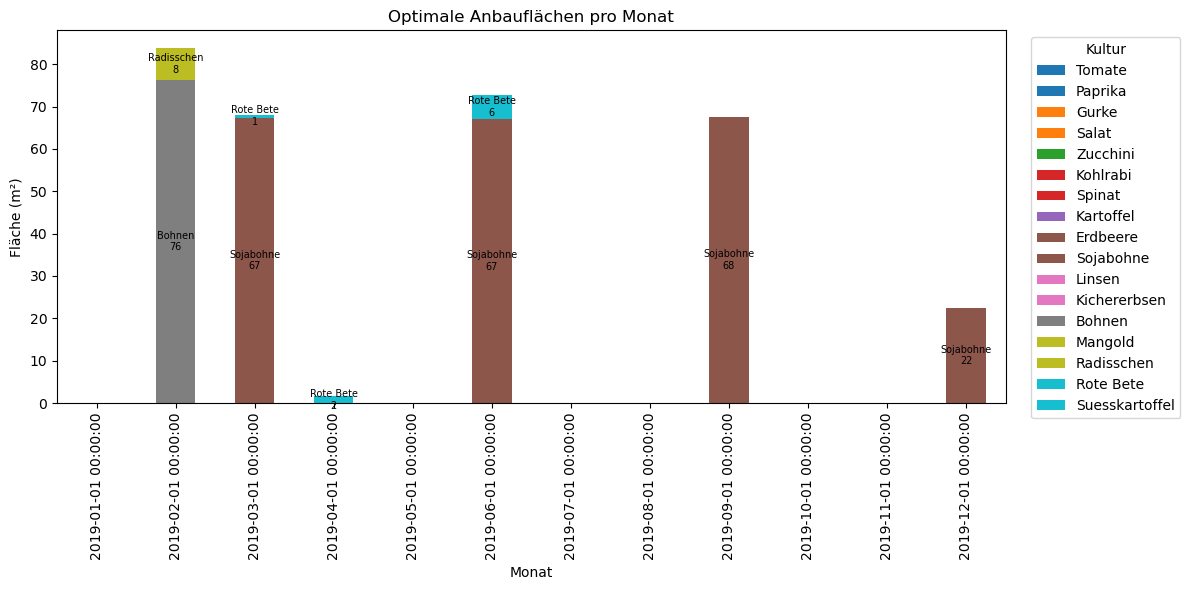

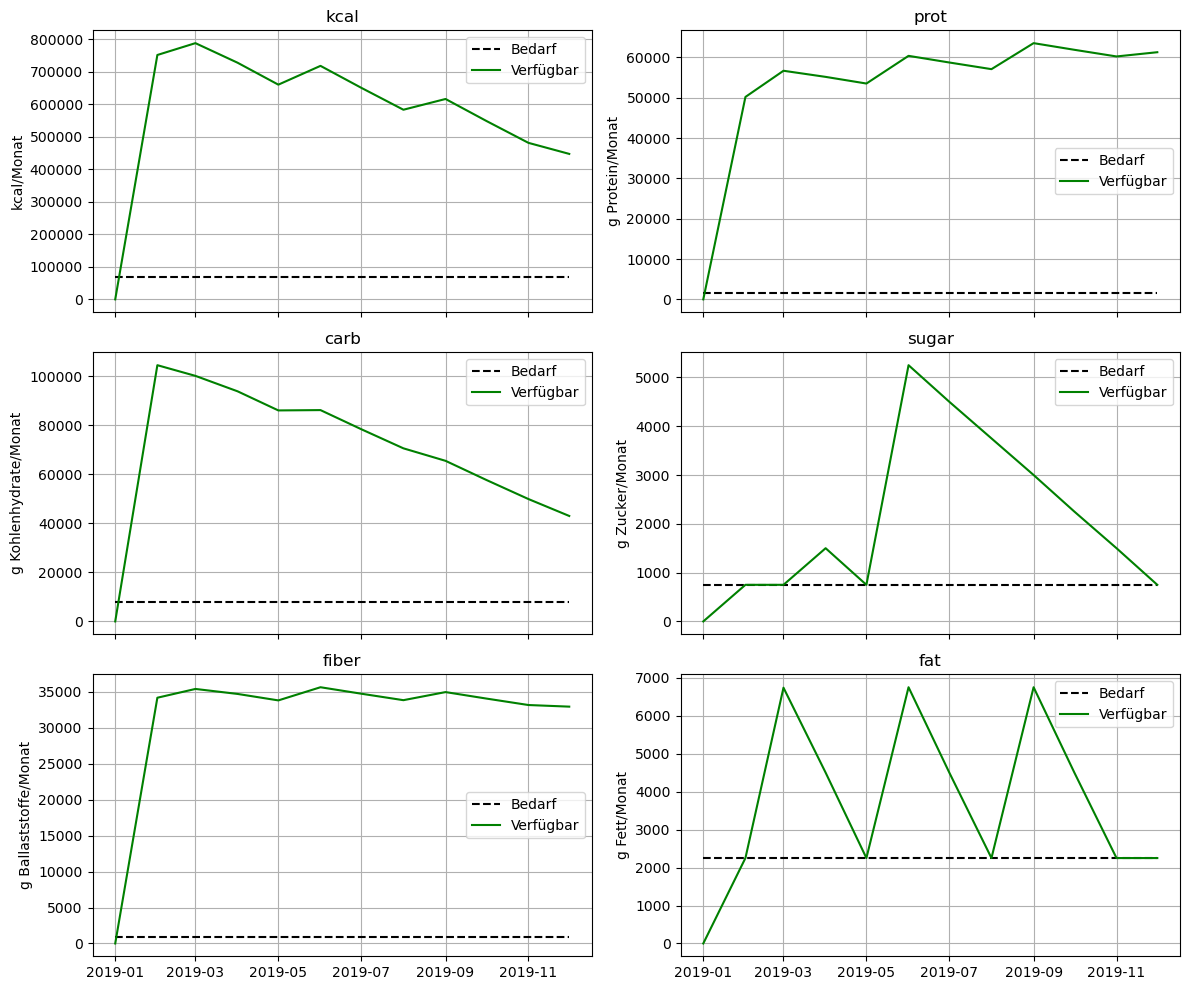

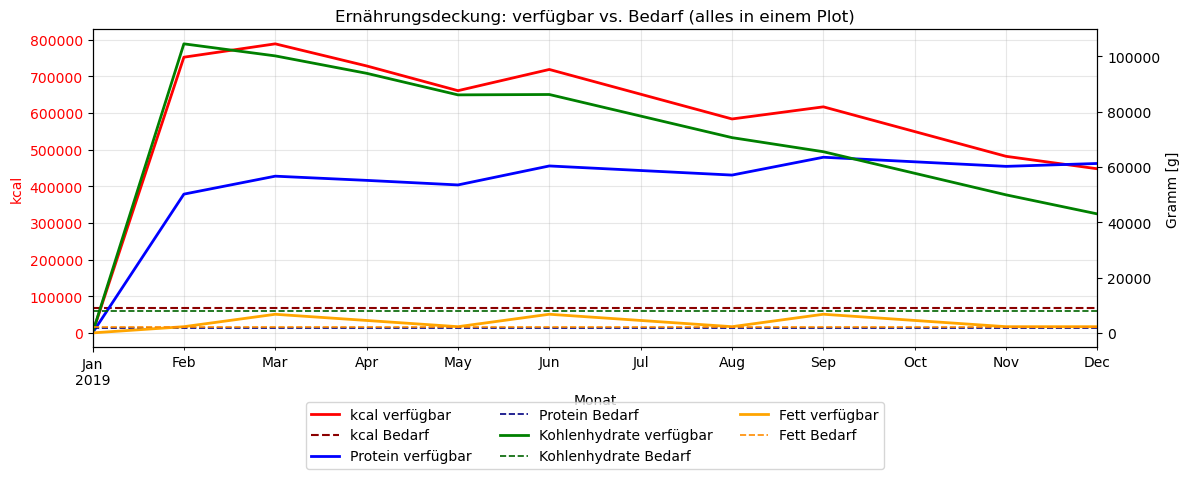

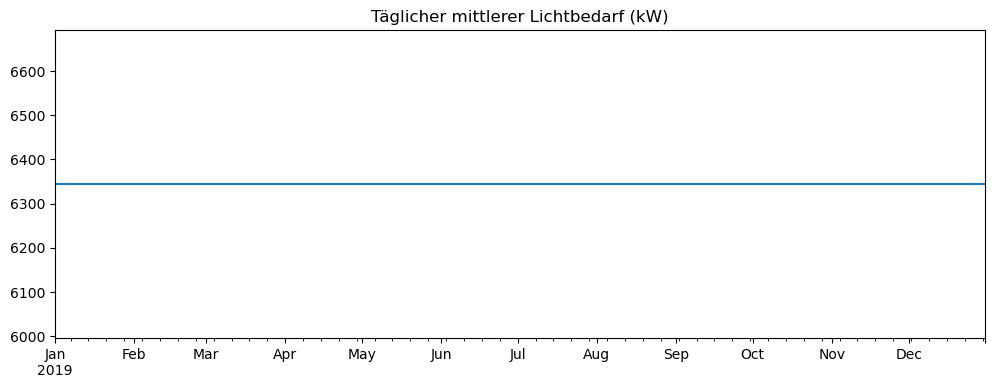

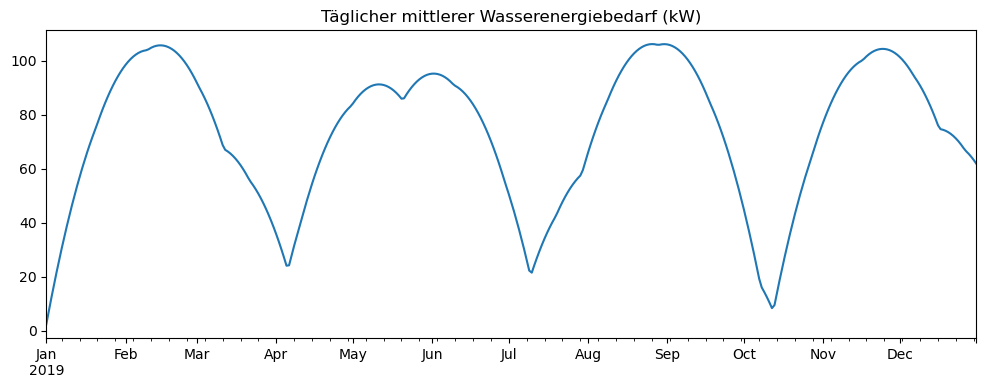

In [24]:
# Optimale Fläche pro Kultur/Monat in DataFrame
df_area = area_opt.to_pandas()
print("\nOptimale Flächen (m²):")
print(df_area.round(1))

max_used_area = df_area.sum(axis=1).max()
print(f"\nMaximal gleichzeitig genutzte Fläche: {max_used_area:.1f} m²")


# Gebaute Kulturen

# Kompakte Übersicht
df_built = (
    pd.DataFrame({"gebaut": built_from_area, "Jahresfläche [m²]": area_year})
    .query("gebaut == 1")
    .sort_values("Jahresfläche [m²]", ascending=False)
    .round(1)
)
print("\nÜbersicht gebaute Kulturen (aus Fläche):")
print(df_built)

# Monate je Kultur
def months_active(da):
    s = da.to_pandas() > 1e-6
    return ", ".join(s.index[s].strftime("%b"))

print("\nMonate je Kultur (falls gebaut, aus Fläche):")
for crop in grown_crops:
    print(f"- {crop}: {months_active(area_opt.sel(crop=crop))}")

print("\nGebaut:")
print(build_opt.to_pandas().astype(int))
# --- Welche Kulturen wurden wirklich gebaut? (1 = gebaut) ---
built = build_opt.to_pandas().astype(int)

# Nur Namen der gebauten Kulturen
grown_crops = built[built == 1].index.tolist()
print("\nAngebaut werden:", ", ".join(grown_crops) if grown_crops else "keine")

# Jahresfläche pro Kultur (Summe über Monate)
area_year = area_opt.sum("snapshot").to_pandas()

# Kompakte Übersichtstabelle der gebauten Kulturen
df_built = (
    pd.DataFrame({
        "gebaut": built,
        "Jahresfläche [m²]": area_year
    })
    .query("gebaut == 1")
    .sort_values("Jahresfläche [m²]", ascending=False)
    .round(1)
)
print("\nÜbersicht gebaute Kulturen:")
print(df_built)

# (Optional) Monate, in denen je Kultur tatsächlich angebaut wurde
def months_active(da):
    s = da.to_pandas() > 1e-6  # kleiner Schwellenwert
    return ", ".join(s.index[s].strftime("%b"))

print("\nMonate je Kultur (falls gebaut):")
for crop in grown_crops:
    print(f"- {crop}: {months_active(area_opt.sel(crop=crop))}")

ax = df_area.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab10")
plt.title("Optimale Anbauflächen pro Monat")
plt.ylabel("Fläche (m²)")
plt.xlabel("Monat")
# Legende rechts außerhalb
plt.legend(title="Kultur", labels=crops, bbox_to_anchor=(1.02, 1), loc="upper left")
# Beschriftung in die Balken (Crop + Fläche)
for container, crop in zip(ax.containers, crops):
    labels = [f"{crop}\n{w:.0f}" if w > 0 else "" for w in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=7, color="black")

plt.tight_layout()
plt.show()



# Produktion jetzt NUMERISCH aus gelöster Fläche (kein .evaluate() nötig)
harvest_sol = yield_per_area * area_opt   # kg

prod_kcal_sol  = (harvest_sol * kcal_per_kg ).sum("crop")   # kcal/Monat
prod_prot_sol  = (harvest_sol * prot_per_kg ).sum("crop")   # g/Monat
prod_carb_sol  = (harvest_sol * carb_per_kg ).sum("crop")
prod_sugar_sol = (harvest_sol * sugar_per_kg).sum("crop")
prod_fiber_sol = (harvest_sol * fiber_per_kg).sum("crop")
prod_fat_sol   = (harvest_sol * fat_per_kg ).sum("crop")

def available_this_month(stock_sol, prod_sol):
    # Vorlauf um 1 Monat: Lager(t-1); erste Periode wird mit 0 gefüllt
    stock_prev = stock_sol.shift(snapshot=1, fill_value=0)
    return stock_prev + prod_sol

avail = {
    "kcal":  available_this_month(stocks_opt["stock_kcal"],  prod_kcal_sol),
    "prot":  available_this_month(stocks_opt["stock_prot"],  prod_prot_sol),
    "carb":  available_this_month(stocks_opt["stock_carb"],  prod_carb_sol),
    "sugar": available_this_month(stocks_opt["stock_sugar"], prod_sugar_sol),
    "fiber": available_this_month(stocks_opt["stock_fiber"], prod_fiber_sol),
    "fat":   available_this_month(stocks_opt["stock_fat"],   prod_fat_sol),
}

# ----------------------------
# 7) Plots: Bedarf vs. Verfügbarkeit
# ----------------------------
fig, axs = plt.subplots(3, 2, figsize=(12,10), sharex=True)
axs = axs.ravel()

nutrients = [
    ("kcal",  demand_kcal,  "kcal/Monat"),
    ("prot",  demand_prot,  "g Protein/Monat"),
    ("carb",  demand_carb,  "g Kohlenhydrate/Monat"),
    ("sugar", demand_sugar, "g Zucker/Monat"),
    ("fiber", demand_fiber, "g Ballaststoffe/Monat"),
    ("fat",   demand_fat,   "g Fett/Monat"),
]

for ax, (key, demand_series, ylabel) in zip(axs, nutrients):
    ax.plot(demand_series.snapshot, demand_series, "k--", label="Bedarf")
    ax.plot(demand_series.snapshot, avail[key], "g-", label="Verfügbar")
    ax.set_title(key)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# === Alles-in-einem-Plot: links kcal, rechts g (Prot/Carb/Fat) ===
def monthly_available(stock_sol: xr.DataArray, prod_sol: xr.DataArray) -> xr.DataArray:
    stock_prev = stock_sol.shift(snapshot=1, fill_value=0)
    return (stock_prev + prod_sol).rename(stock_sol.name.replace("stock_", "avail_"))

# Verfügbar-Bilanzen aus deinen gelösten Variablen
avail_kcal = monthly_available(stocks_opt["stock_kcal"],  prod_kcal_sol)
avail_prot = monthly_available(stocks_opt["stock_prot"],  prod_prot_sol)
avail_carb = monthly_available(stocks_opt["stock_carb"],  prod_carb_sol)
avail_fat  = monthly_available(stocks_opt["stock_fat"],   prod_fat_sol)

# Ein Diagramm mit Zwillingsachse
fig, ax1 = plt.subplots(figsize=(12,5))

# Linke Y-Achse: kcal
avail_kcal.to_pandas().plot(ax=ax1, lw=2, color="red", label="kcal verfügbar")
demand_kcal.to_pandas().plot(ax=ax1, style="--", lw=1.5, color="darkred", label="kcal Bedarf")
ax1.set_ylabel("kcal", color="red")
ax1.tick_params(axis="y", labelcolor="red")

# Rechte Y-Achse: Makros in g
ax2 = ax1.twinx()
# Protein (blau)
avail_prot.to_pandas().plot(ax=ax2, lw=2, color="blue", label="Protein verfügbar")
demand_prot.to_pandas().plot(ax=ax2, style="--", lw=1.2, color="navy", label="Protein Bedarf")

# Kohlenhydrate (grün)
avail_carb.to_pandas().plot(ax=ax2, lw=2, color="green", label="Kohlenhydrate verfügbar")
demand_carb.to_pandas().plot(ax=ax2, style="--", lw=1.2, color="darkgreen", label="Kohlenhydrate Bedarf")

# Fett (orange)
avail_fat.to_pandas().plot(ax=ax2, lw=2, color="orange", label="Fett verfügbar")
demand_fat.to_pandas().plot(ax=ax2, style="--", lw=1.2, color="darkorange", label="Fett Bedarf")

ax2.set_ylabel("Gramm [g]")

# Titel, Gitter, Legende außen
ax1.set_title("Ernährungsdeckung: verfügbar vs. Bedarf (alles in einem Plot)")
ax1.set_xlabel("Monat")
ax1.grid(True, which="both", axis="both", alpha=0.3)

# Legende außerhalb platzieren
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1+h2, l1+l2, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.tight_layout()
plt.show()



# =====================================================
# 8) Profile für Licht & Wasser der angebauten Pflanzen
# =====================================================

# Hilfsfunktionen
def light_profile_16on_8off(snapshots):
    day_hours = np.arange(len(snapshots)) % 24
    on = (day_hours < 16).astype(float)
    return pd.Series(on, index=snapshots)  # normiert auf 1 kW/m²

def water_profile_parabola_cycle(T_days, b_kWh_per_m2_day, snapshots,
                                 start_hour=0, Wmin_kWh_per_m2_day=0.0):
    T_h = int(round(float(T_days) * 24))
    if T_h <= 0 or b_kWh_per_m2_day < 0:
        return pd.Series(0.0, index=snapshots)
    hours = np.arange(len(snapshots))
    tau = (hours - int(start_hour)) % T_h
    t_days = tau / 24.0
    core = 1.0 - ((t_days - T_days/2)/(T_days/2))**2
    core = np.clip(core, 0.0, None)
    day_need = Wmin_kWh_per_m2_day + (b_kWh_per_m2_day - Wmin_kWh_per_m2_day)*core
    return pd.Series(day_need/24.0, index=snapshots)

# Beispiel-Parameter je Pflanze (kannst du mit echten Daten füllen!) # "Tomate","Paprika","Gurke","Salat","Zucchini","Kohlrabi",
#          "Spinat","Kartoffel","Erdbeere","Sojabohne"
plant_params = {

    "Tomate":       {"light_kwh_per_m2": 144, "water_T_days": 84, "water_peak": 7, "water_min": 0},
    "Paprika":      {"light_kwh_per_m2": 75, "water_T_days": 110, "water_peak": 9, "water_min": 0},
    "Gurke":        {"light_kwh_per_m2": 11, "water_T_days": 28, "water_peak": 5, "water_min": 0},
    "Salat":        {"light_kwh_per_m2": 444, "water_T_days": 120, "water_peak": 6, "water_min": 0},
    "Zucchini":     {"light_kwh_per_m2": 116, "water_T_days": 100, "water_peak": 7, "water_min": 0},
    "Kohlrabi":     {"light_kwh_per_m2": 128, "water_T_days": 90, "water_peak": 5, "water_min": 0},
    "Spinat":       {"light_kwh_per_m2": 52, "water_T_days": 28, "water_peak": 4, "water_min": 0},
    "Kartoffel":    {"light_kwh_per_m2": 187, "water_T_days": 90, "water_peak":7, "water_min": 0},
    "Erdbeere":     {"light_kwh_per_m2": 65, "water_T_days": 90, "water_peak":4, "water_min": 0},
    "Sojabohne":    {"light_kwh_per_m2": 19, "water_T_days": 95, "water_peak":9, "water_min": 0},
    "Linsen":       {"light_kwh_per_m2": 19, "water_T_days": 100, "water_peak":6, "water_min": 0},
    "Kichererbsen": {"light_kwh_per_m2": 187, "water_T_days": 105, "water_peak": 5, "water_min": 0},
    "Bohnen":       {"light_kwh_per_m2": 65, "water_T_days": 70, "water_peak": 7, "water_min": 0},
    "Mangold":      {"light_kwh_per_m2": 19, "water_T_days": 40, "water_peak": 5, "water_min": 0},
    "Radisschen":   {"light_kwh_per_m2": 19, "water_T_days": 20, "water_peak": 3, "water_min": 0},
    "Rote Bete":    {"light_kwh_per_m2": 19, "water_T_days": 40, "water_peak": 4, "water_min": 0},
    "Suesskartoffel": {"light_kwh_per_m2": 19, "water_T_days": 120, "water_peak": 7, "water_min": 0},

}

# Neue stündliche Zeitachse (1 Jahr)
snapshots_h = pd.date_range("2019-01-01", periods=8760, freq="h")

profiles_light = {}
profiles_water = {}

for crop in crops:
    area_crop = area_opt.sel(crop=crop).sum().item()  # gesamte Jahresfläche der Pflanze
    if area_crop > 0.1:  # nur wenn wirklich angebaut
        p = plant_params[crop]

        # Licht: Grundprofil (0/1) * Leistung je m² * Fläche
        prof_light = light_profile_16on_8off(snapshots_h) * p["light_kwh_per_m2"] * area_crop
        profiles_light[crop] = prof_light

        # Wasser: Parabol-Profil * Fläche
        prof_water = water_profile_parabola_cycle(
            T_days=p["water_T_days"],
            b_kWh_per_m2_day=p["water_peak"],
            snapshots=snapshots_h,
            start_hour=0,
            Wmin_kWh_per_m2_day=p["water_min"]
        ) * area_crop
        profiles_water[crop] = prof_water

# Gesamtlasten aufsummieren
total_light = sum(profiles_light.values())
total_water = sum(profiles_water.values())

# Plots
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
total_light.resample("D").mean().plot()
plt.title("Täglicher mittlerer Lichtbedarf (kW)")
plt.show()

plt.figure(figsize=(12,4))
total_water.resample("D").mean().plot()
plt.title("Täglicher mittlerer Wasserenergiebedarf (kW)")
plt.show()